# Instrucciones para Resolver Sistemas Ax=b y By=b

Se te proporciona una serie de tablas en la cual la última columna corresponde a un elemento conocido como **etiqueta**, y el resto de columnas se conoce como **características**. Tu tarea es llevar a cabo los siguientes pasos **sin el uso de funciones definidas (`def`)**, para que te familiarices con lo que sucede detrás al usar herramientas como scikit-learn de Python:

### 1. Descomponer las tablas
Descompón las tablas en:
- **Matriz A:** que contiene todas las características.
- **Vector b:** que contiene las etiquetas.

### 2. Generar la Matriz Ampliada B
Genera una matriz ampliada **B** añadiendo una primera columna de $1's$ y el resto con los valores de la matriz **A**, de modo que:
$$ B = [1|A] $$

### 3. Cálculo del Determinante
En los casos en que sea posible, calcula el determinante de las matrices **A** y **B**:
- Determinante de **A**: $ \text{det}(A) $
- Determinante de **B**: $ \text{det}(B) $

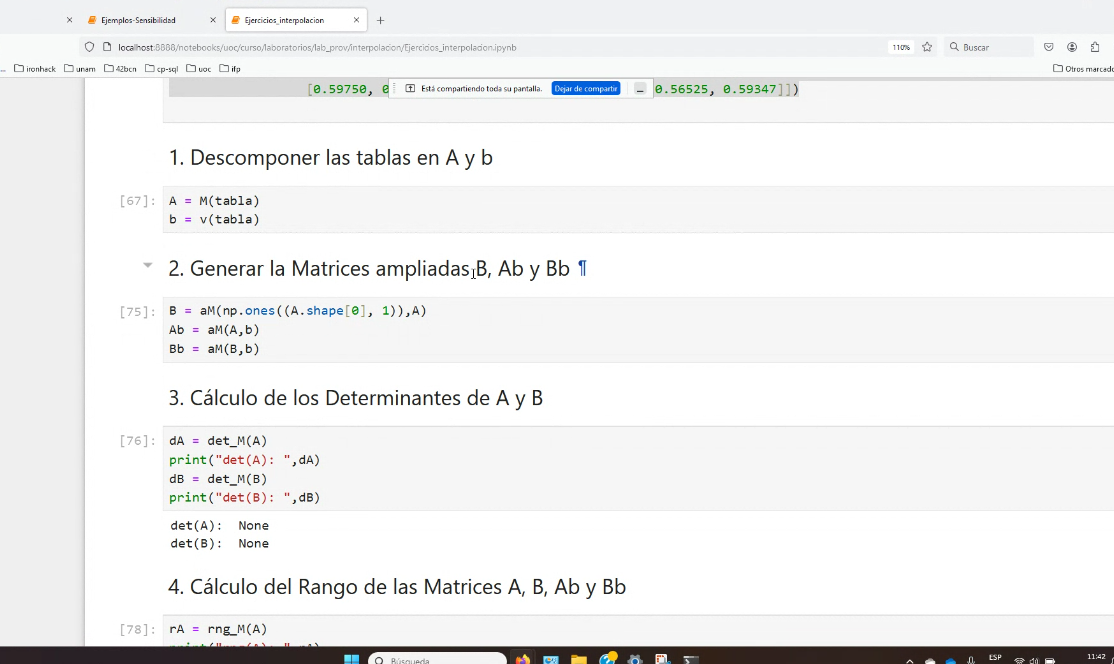

### 4. Cálculo del Rango
Calcula el rango de las matrices:
- **Rango de A**: $ \text{rank}(A) $
- **Rango de B**: $ \text{rank}(B) $

También, calcula el rango de las matrices ampliadas **[A|b]** y **[B|b]**:
$$ \text{rank}( [A|b] ) \quad \text{y} \quad \text{rank}( [B|b] ) $$

### 5. Clasificación de los Sistemas
Clasifica los sistemas:
- **Ax=b**
- **By=b**

según la clasificación de sistemas de ecuaciones lineales (determinado, indeterminado, o incompatible) basado en los rangos obtenidos.

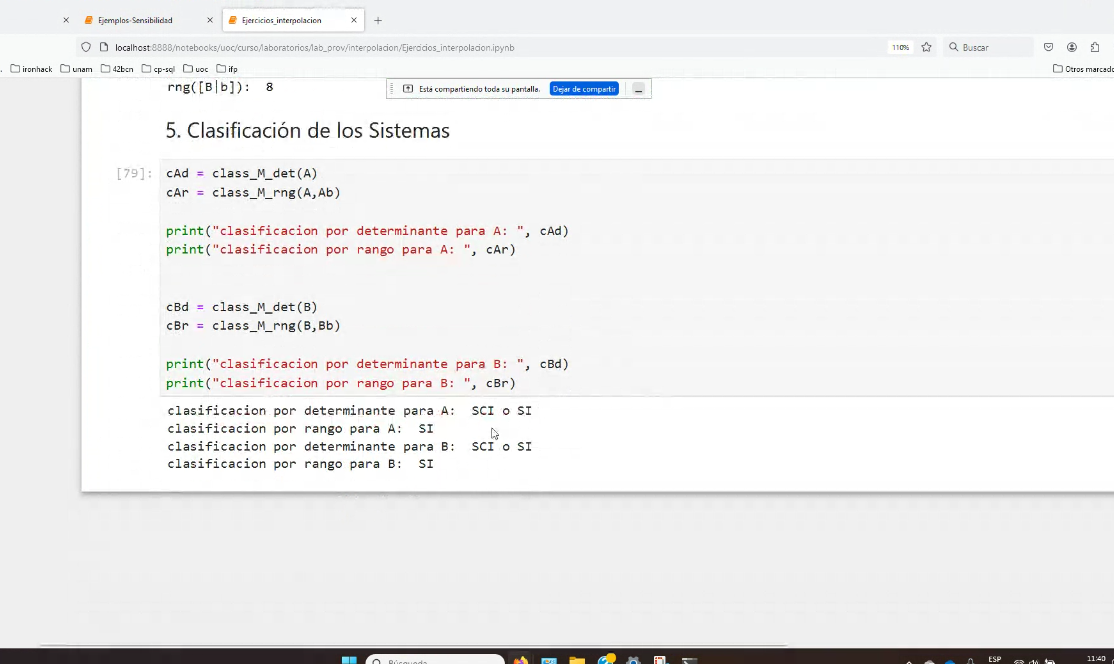

### 6. Resolución de los Sistemas
Resuelve los sistemas utilizando:
- **Matriz inversa** si el sistema es determinado: $ x = A^{-1}b $
- **Pseudoinversa** en caso de ser un sistema indeterminado: $ x = A^{+}b $

Haz lo mismo para **B**:
$$ y = B^{-1}b \quad \text{o} \quad y = B^{+}b $$

### 7. Análisis de Estabilidad
Realiza un análisis de estabilidad de los sistemas a través de dilataciones y contracciones de las soluciones en factores del:
- $0.5\%$, $1\%$, $2\%$, $5\%$, y $10\%$.

Analiza los cambios porcentuales que se generan en las soluciones $b'$ perturbadas en relación con la $b$ real.

### 8. Intervalos de Confianza
Con el análisis anterior, establece una clase de intervalos de confianza en terminos de porcentaje para las soluciones obtenidas, considerando que:
- Las **dilataciones** podrían simular el redondeo o pérdida de precisión en los decimales de las soluciones.
- Las **contracciones** podrían simular errores numéricos pequeños o fluctuaciones en los datos originales.

### 9. Interpolantes
Las soluciones de los sistemas **Ax=b** y **By=b** pueden utilizarse para construir interpolantes:
- **Sin término independiente** para **Ax=b**.
- **Con término independiente** para **By=b**.

Construye dichos interpolantes.

### 10. Comparación de los Interpolantes
Analiza cuál de los interpolantes proporciona una solución más cercana a los valores de $b$, y argumenta si eso sería suficiente para justificar si es una mejor solución para el problema de interpolación.

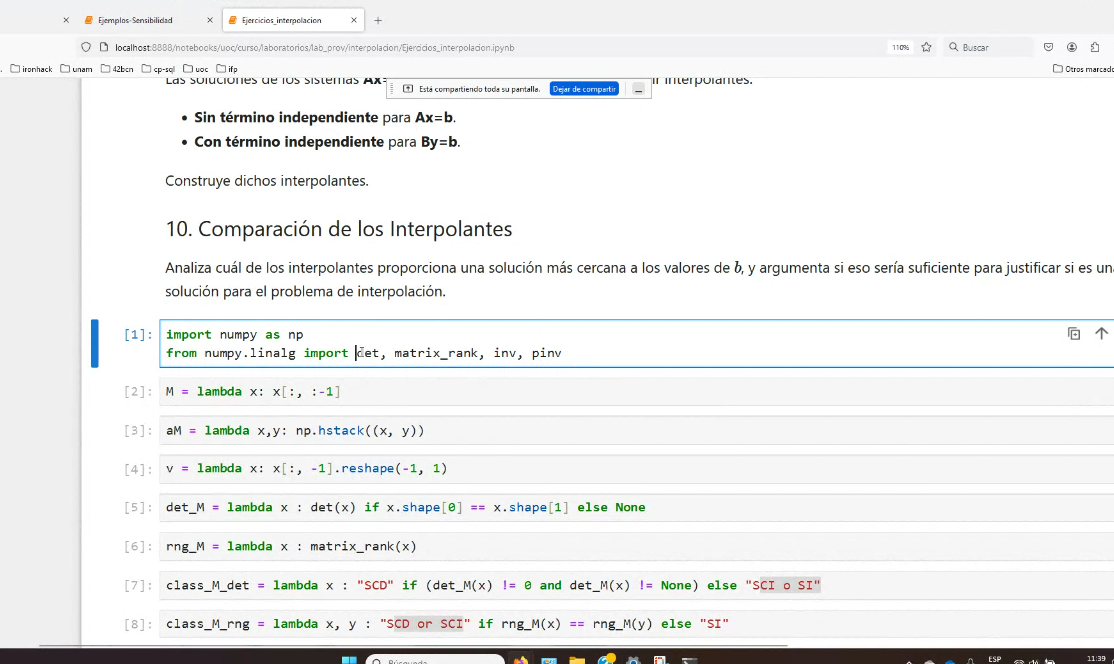

In [1]:
import numpy as np
import time


In [2]:
# tabla (6x6)
tabla1 = np.array([[0.32047, 0.82356, 0.25645, 0.49580, 0.67355, 0.61427],
                  [0.29187, 0.44708, 0.19897, 0.89325, 0.73233, 0.89347],
                  [0.13883, 0.64831, 0.02541, 0.84798, 0.57868, 0.37958],
                  [0.89019, 0.36956, 0.23375, 0.45624, 0.18749, 0.25037],
                  [0.54278, 0.18745, 0.96885, 0.25942, 0.65492, 0.12485],
                  [0.76956, 0.06538, 0.49874, 0.82947, 0.86217, 0.78432]])


In [3]:
# tabla (6x6)
tabla2 = np.array([[0.42533, 0.30128, 0.67274, 0.56891, 0.84945, 0.61348],
                  [0.89747, 0.25390, 0.18011, 0.45375, 0.61618, 0.23765],
                  [0.53472, 0.74909, 0.10292, 0.92582, 0.42937, 0.97256],
                  [0.82625, 0.66803, 0.48776, 0.61463, 0.06765, 0.81539],
                  [0.16523, 0.81656, 0.41254, 0.72114, 0.82603, 0.15945],
                  [0.72064, 0.37514, 0.57535, 0.25643, 0.53927, 0.69474]])


In [4]:
# tabla (8x7)
tabla3 = np.array([[0.74898, 0.28122, 0.52920, 0.56900, 0.91599, 0.26114, 0.85767],
                  [0.87788, 0.57300, 0.21391, 0.18360, 0.27809, 0.47191, 0.52021],
                  [0.87446, 0.54117, 0.65085, 0.02731, 0.92548, 0.95857, 0.84126],
                  [0.44242, 0.31208, 0.45062, 0.48809, 0.24730, 0.08539, 0.49884],
                  [0.36721, 0.45338, 0.60793, 0.01837, 0.66224, 0.12615, 0.33194],
                  [0.54924, 0.69931, 0.05451, 0.81977, 0.56267, 0.36233, 0.99719],
                  [0.77000, 0.20419, 0.72319, 0.47703, 0.62884, 0.70215, 0.00228],
                  [0.59750, 0.39309, 0.90533, 0.88076, 0.34626, 0.56525, 0.59347]])


In [5]:
# tabla (8x7)
tabla4 = np.array([[0.43217, 0.27185, 0.63925, 0.14753, 0.65845, 0.72451, 0.92756],
                  [0.85973, 0.55467, 0.10348, 0.38429, 0.97862, 0.30109, 0.36874],
                  [0.18459, 0.66988, 0.47842, 0.82746, 0.13367, 0.93471, 0.74512],
                  [0.04917, 0.76520, 0.56264, 0.05618, 0.31561, 0.90881, 0.09857],
                  [0.70551, 0.97730, 0.84481, 0.27559, 0.12154, 0.54392, 0.64783],
                  [0.96104, 0.86563, 0.05429, 0.34809, 0.25537, 0.21155, 0.28367],
                  [0.57384, 0.78641, 0.19932, 0.14379, 0.47252, 0.20055, 0.18792],
                  [0.31864, 0.96378, 0.48521, 0.11467, 0.89523, 0.69090, 0.45634]])

In [6]:
# tabla (6x7)
tabla5 = np.array([[0.42074, 0.65412, 0.71950, 0.81775, 0.39471, 0.74543, 0.67315],
                  [0.12866, 0.89460, 0.56291, 0.21824, 0.99422, 0.40157, 0.58752],
                  [0.51278, 0.70214, 0.28451, 0.45349, 0.07861, 0.13209, 0.24194],
                  [0.89752, 0.67005, 0.46527, 0.84486, 0.87365, 0.26328, 0.45833],
                  [0.18930, 0.49567, 0.95384, 0.27422, 0.10112, 0.65198, 0.78461],
                  [0.36893, 0.76034, 0.01245, 0.21353, 0.07645, 0.84261, 0.03150]])


In [7]:
# tabla (8x7)
tabla6 = np.array([[0.74898, 0.28122, 0.52920, 0.56900, 0.91599, 0.26114, 0.85767],
                  [0.87788, 0.57300, 0.21391, 0.18360, 0.27809, 0.47191, 0.52021],
                  [0.87446, 0.54117, 0.65085, 0.02731, 0.92548, 0.95857, 0.84126],
                  [0.44242, 0.31208, 0.45062, 0.48809, 0.24730, 0.08539, 0.49884],
                  [0.36721, 0.45338, 0.60793, 0.01837, 0.66224, 0.12615, 0.33194],
                  [0.54924, 0.69931, 0.05451, 0.81977, 0.56267, 0.36233, 0.99719],
                  [0.77000, 0.20419, 0.72319, 0.47703, 0.62884, 0.70215, 0.00228],
                  [0.59750, 0.39309, 0.90533, 0.88076, 0.34626, 0.56525, 0.59347]])


In [8]:
tablas = [ 
    {"datos" : tabla1, "nombre" : "tabla1"}, 
    {"datos" : tabla2, "nombre" : "tabla2"},
    {"datos" : tabla3, "nombre" : "tabla3"},
    {"datos" : tabla4, "nombre" : "tabla4"},
    {"datos" : tabla5, "nombre" : "tabla5"},
    {"datos" : tabla6, "nombre" : "tabla6"}
]

### 1. Descomponer las tablas
Descompón las tablas en:
- **Matriz A:** que contiene todas las características.
- **Vector b:** que contiene las etiquetas.

In [9]:
def descomponer_tabla(tabla):
    A = tabla[:,:-1:]
    b = tabla[:,-1:]
    return A, b

In [10]:

for tabla in tablas:
    tabla["A"], tabla["b"] = descomponer_tabla(tabla["datos"])

print(tablas[0]["datos"])
print(tablas[0]["A"])
print(tablas[0]["b"])

[[0.32047 0.82356 0.25645 0.4958  0.67355 0.61427]
 [0.29187 0.44708 0.19897 0.89325 0.73233 0.89347]
 [0.13883 0.64831 0.02541 0.84798 0.57868 0.37958]
 [0.89019 0.36956 0.23375 0.45624 0.18749 0.25037]
 [0.54278 0.18745 0.96885 0.25942 0.65492 0.12485]
 [0.76956 0.06538 0.49874 0.82947 0.86217 0.78432]]
[[0.32047 0.82356 0.25645 0.4958  0.67355]
 [0.29187 0.44708 0.19897 0.89325 0.73233]
 [0.13883 0.64831 0.02541 0.84798 0.57868]
 [0.89019 0.36956 0.23375 0.45624 0.18749]
 [0.54278 0.18745 0.96885 0.25942 0.65492]
 [0.76956 0.06538 0.49874 0.82947 0.86217]]
[[0.61427]
 [0.89347]
 [0.37958]
 [0.25037]
 [0.12485]
 [0.78432]]


### 2. Generar la Matriz Ampliada B
Genera una matriz ampliada **B** añadiendo una primera columna de $1's$ y el resto con los valores de la matriz **A**, de modo que:
$$ B = [1|A] $$

In [11]:
def Ampliada(b, A):
    return np.hstack((b, A))



In [12]:
for tabla in tablas:
    tabla["B"] = Ampliada(np.ones((tabla["A"].shape[0], 1)), tabla["A"])
    tabla["Ab"] = Ampliada(tabla["A"], tabla["b"])
    tabla["Bb"] = Ampliada(tabla["B"], tabla["b"])

print(tablas[0]["B"])


[[1.      0.32047 0.82356 0.25645 0.4958  0.67355]
 [1.      0.29187 0.44708 0.19897 0.89325 0.73233]
 [1.      0.13883 0.64831 0.02541 0.84798 0.57868]
 [1.      0.89019 0.36956 0.23375 0.45624 0.18749]
 [1.      0.54278 0.18745 0.96885 0.25942 0.65492]
 [1.      0.76956 0.06538 0.49874 0.82947 0.86217]]


### 3. Cálculo del Determinante
En los casos en que sea posible, calcula el determinante de las matrices **A** y **B**:
- Determinante de **A**: $ \text{det}(A) $
- Determinante de **B**: $ \text{det}(B) $



In [13]:
def np_det(A):
    try:
        return np.linalg.det(A)
    except np.linalg.LinAlgError as e:
        return None


In [14]:
for tabla in tablas:
    tabla["det_A"] = np_det(tabla["A"])
    tabla["det_A_b"] = np_det(tabla["Ab"])
    tabla["det_B"] = np_det(tabla["B"])
    tabla["det_B_b"] = np_det(tabla["Bb"])

print(tablas[0]["det_A"], tablas[0]["det_A_b"], tablas[0]["det_B"], tablas[0]["det_B_b"])

None -0.048310267254011906 -0.0016271442410992075 None


### 4. Cálculo del Rango
Calcula el rango de las matrices:
- **Rango de A**: $ \text{rank}(A) $
- **Rango de B**: $ \text{rank}(B) $

También, calcula el rango de las matrices ampliadas **[A|b]** y **[B|b]**:
$$ \text{rank}( [A|b] ) \quad \text{y} \quad \text{rank}( [B|b] ) $$

In [15]:
for tabla in tablas:
    tabla["rank_A"] = np.linalg.matrix_rank(tabla["A"])
    tabla["rank_A_b"] = np.linalg.matrix_rank(tabla["Ab"])
    tabla["rank_B"] = np.linalg.matrix_rank(tabla["B"])
    tabla["rank_B_b"] = np.linalg.matrix_rank(tabla["Bb"])

print(tablas[0]["rank_A"], tablas[0]["rank_A_b"], tablas[0]["rank_B"], tablas[0]["rank_B_b"])

5 6 6 6


### 5. Clasificación de los Sistemas
Clasifica los sistemas:
- **Ax=b**
- **By=b**

según la clasificación de sistemas de ecuaciones lineales (determinado, indeterminado, o incompatible) basado en los rangos obtenidos.

In [16]:
def clasifica(rank_A, rank_A_b, n_A):
    # Segun documentacion de pag 9 de Interpolacion-Extrapolacion.pdf
    if rank_A == rank_A_b :
        if rank_A == n_A:
            return "Sistema Compatible Determinado (SCD)"
        elif rank_A < n_A:
            return "Sistema Compatible Indeterminado (SCI)"
    else:
        return "Sistema Incompatible (SIC)"

In [17]:
for tabla in tablas:
    tabla["n_A"] = len(tabla["A"][0])
    tabla["n_B"] = len(tabla["B"][0])
    tabla["clase_A"] = clasifica(tabla["rank_A"], tabla["rank_A_b"], tabla["n_A"])
    tabla["clase_B"] = clasifica(tabla["rank_B"], tabla["rank_B_b"], tabla["n_B"])

print(tablas[0]["clase_A"], tablas[0]["n_A"])

Sistema Incompatible (SIC) 5


In [18]:

for tabla in tablas:

    print ("\n#######",tabla["nombre"], "########") 
    print ("\n- Matriz A:", tabla["clase_A"]) 
    print ("\tdet =", tabla["det_A"], "\trank =", tabla["rank_A"], "\tn =", tabla["n_A"],"\trank(A|b) =", tabla["rank_A_b"] )
    print ("\n- Matriz B:", tabla["clase_B"]) 
    print ("\tdet =", tabla["det_B"], "\trank =", tabla["rank_B"], "\tn =", tabla["n_B"],"\trank(B|b) =", tabla["rank_B_b"] )



####### tabla1 ########

- Matriz A: Sistema Incompatible (SIC)
	det = None 	rank = 5 	n = 5 	rank(A|b) = 6

- Matriz B: Sistema Compatible Determinado (SCD)
	det = -0.0016271442410992075 	rank = 6 	n = 6 	rank(B|b) = 6

####### tabla2 ########

- Matriz A: Sistema Incompatible (SIC)
	det = None 	rank = 5 	n = 5 	rank(A|b) = 6

- Matriz B: Sistema Compatible Determinado (SCD)
	det = 0.004879188221007908 	rank = 6 	n = 6 	rank(B|b) = 6

####### tabla3 ########

- Matriz A: Sistema Incompatible (SIC)
	det = None 	rank = 6 	n = 6 	rank(A|b) = 7

- Matriz B: Sistema Incompatible (SIC)
	det = None 	rank = 7 	n = 7 	rank(B|b) = 8

####### tabla4 ########

- Matriz A: Sistema Incompatible (SIC)
	det = None 	rank = 6 	n = 6 	rank(A|b) = 7

- Matriz B: Sistema Incompatible (SIC)
	det = None 	rank = 7 	n = 7 	rank(B|b) = 8

####### tabla5 ########

- Matriz A: Sistema Compatible Determinado (SCD)
	det = -0.14396980921237948 	rank = 6 	n = 6 	rank(A|b) = 6

- Matriz B: Sistema Compatible Indeter

### 6. Resolución de los Sistemas
Resuelve los sistemas utilizando:
- **Matriz inversa** si el sistema es determinado: $ x = A^{-1}b $
- **Pseudoinversa** en caso de ser un sistema indeterminado: $ x = A^{+}b $

Haz lo mismo para **B**:
$$ y = B^{-1}b \quad \text{o} \quad y = B^{+}b $$

In [19]:
def np_inv(A):
    try:
        return np.linalg.inv(A)
    except np.linalg.LinAlgError as e:
        return None

def np_pinv(A):
    try:
        return np.linalg.pinv(A)
    except np.linalg.LinAlgError as e:
        return None

def np_dot(inv_A, b):
    try:
        return np.dot(inv_A, b)
    except np.linalg.LinAlgError as e:
        return None
    except TypeError as e:
        return None


In [20]:

for tabla in tablas:
    tabla["sol_inv_A"] = tabla["sol_inv_B"] = tabla["sol_pinv_A"] = tabla["sol_pinv_B"] = None
    
    if tabla["clase_A"] == "Sistema Compatible Determinado (SCD)":
        tabla["inv_A"] = np_inv(tabla["A"])
        tabla["inv_A_dot_b"] = np_dot(tabla["inv_A"], tabla["b"])
        tabla["sol_inv_A"] = np_dot(tabla["A"], tabla["inv_A_dot_b"])
    elif tabla["clase_A"] == "Sistema Compatible Indeterminado (SCI)":
        tabla["pinv_A"] = np_pinv(tabla["A"])
        tabla["pinv_A_dot_b"] = np_dot(tabla["pinv_A"], tabla["b"])
        tabla["sol_pinv_A"] = np_dot(tabla["A"], tabla["pinv_A_dot_b"])

    if tabla["clase_B"] == "Sistema Compatible Determinado (SCD)":
        tabla["inv_B"] = np_inv(tabla["B"])
        tabla["inv_B_dot_b"] = np_dot(tabla["inv_B"], tabla["b"])
        tabla["sol_inv_B"] = np_dot(tabla["B"], tabla["inv_B_dot_b"])
    elif tabla["clase_B"] == "Sistema Compatible Indeterminado (SCI)":
        tabla["pinv_B"] = np_pinv(tabla["B"])
        tabla["pinv_B_dot_b"] = np_dot(tabla["pinv_B"], tabla["b"])
        tabla["sol_pinv_B"] = np_dot(tabla["B"], tabla["pinv_B_dot_b"])


for tabla in tablas:
    print ("\n",tabla["nombre"])
    print ("\tClase de A:", tabla["clase_A"])
    if tabla["sol_inv_A"] is not None:
        print("\tSolucion A\n", tabla["sol_inv_A"])
    if tabla["sol_pinv_A"] is not None:
        print("\tSolucion pinv_A\n", tabla["sol_pinv_A"])
    print ("\tClase de B:", tabla["clase_B"])
    if tabla["sol_inv_B"] is not None:
        print("\tSolucion B\n", tabla["sol_inv_B"])
    if tabla["sol_pinv_B"] is not None:
        print("\tSolucion pinv_B\n", tabla["sol_pinv_B"])



 tabla1
	Clase de A: Sistema Incompatible (SIC)
	Clase de B: Sistema Compatible Determinado (SCD)
	Solucion B
 [[0.61427]
 [0.89347]
 [0.37958]
 [0.25037]
 [0.12485]
 [0.78432]]

 tabla2
	Clase de A: Sistema Incompatible (SIC)
	Clase de B: Sistema Compatible Determinado (SCD)
	Solucion B
 [[0.61348]
 [0.23765]
 [0.97256]
 [0.81539]
 [0.15945]
 [0.69474]]

 tabla3
	Clase de A: Sistema Incompatible (SIC)
	Clase de B: Sistema Incompatible (SIC)

 tabla4
	Clase de A: Sistema Incompatible (SIC)
	Clase de B: Sistema Incompatible (SIC)

 tabla5
	Clase de A: Sistema Compatible Determinado (SCD)
	Solucion A
 [[0.67315]
 [0.58752]
 [0.24194]
 [0.45833]
 [0.78461]
 [0.0315 ]]
	Clase de B: Sistema Compatible Indeterminado (SCI)
	Solucion pinv_B
 [[0.67315]
 [0.58752]
 [0.24194]
 [0.45833]
 [0.78461]
 [0.0315 ]]

 tabla6
	Clase de A: Sistema Incompatible (SIC)
	Clase de B: Sistema Incompatible (SIC)


### 7. Análisis de Estabilidad
Realiza un análisis de estabilidad de los sistemas a través de dilataciones y contracciones de las soluciones en factores del:
- $0.5\%$, $1\%$, $2\%$, $5\%$, y $10\%$.

Analiza los cambios porcentuales que se generan en las soluciones $b'$ perturbadas en relación con la $b$ real.

In [21]:
dilataciones = [1.005, 1.01, 1.02, 1.05, 1.10]
contracciones = [0.995, 0.99, 0.98, 0.95, 0.90]

x_perturbadas = lambda x, lista: [x * i for i in lista]
b_perturbadas = lambda M, lista : [M.dot(i) for i in lista]


def error_perturbada(x, factor):
    inv_B_dot_b_dil = x_perturbadas(x, factor)
    return [np.linalg.norm(x - inv_B_dot_b_dil[i]) / np.linalg.norm(x) for i in range(len(factor))]

def error_perturbadas(x, d ,c):
    return error_perturbada(x, d), error_perturbada(x, c)

error_perturbadas(tablas[0]["sol_inv_B"], dilataciones, contracciones)

([np.float64(0.0049999999999999125),
  np.float64(0.009999999999999972),
  np.float64(0.02000000000000004),
  np.float64(0.05),
  np.float64(0.10000000000000009)],
 [np.float64(0.005000000000000056),
  np.float64(0.009999999999999978),
  np.float64(0.02000000000000004),
  np.float64(0.05),
  np.float64(0.09999999999999995)])

In [22]:

for tabla in tablas:

    if tabla["sol_inv_A"] is not None:
        tabla["inv_A_dot_b_dil_err"], tabla["inv_A_dot_b_cont_err"] = error_perturbadas(tabla["inv_A_dot_b"], dilataciones, contracciones)
        tabla["sol_inv_A_dil_err"], tabla["sol_inv_A_cont_err"] = error_perturbadas( tabla["sol_inv_A"], dilataciones, contracciones)

    if tabla["sol_pinv_A"] is not None:
        tabla["pinv_A_dot_b_dil_err"], tabla["pinv_A_dot_b_cont_err"] = error_perturbadas(tabla["pinv_A_dot_b"], dilataciones, contracciones)
        tabla["sol_pinv_A_dil_err"], tabla["sol_pinv_A_cont_err"] = error_perturbadas(tabla["sol_pinv_A"], dilataciones, contracciones)

    if tabla["sol_inv_B"] is not None:
        tabla["inv_B_dot_b_dil_err"], tabla["inv_B_dot_b_cont_err"] = error_perturbadas(tabla["inv_B_dot_b"], dilataciones, contracciones) 
        tabla["sol_inv_B_dil_err"], tabla["sol_inv_B_cont_err"] = error_perturbadas(tabla["sol_inv_B"], dilataciones, contracciones)

    if tabla["sol_pinv_B"] is not None:
        tabla["pinv_B_dot_b_dil_err"], tabla["pinv_B_dot_b_cont_err"] = error_perturbadas(tabla["pinv_B_dot_b"], dilataciones, contracciones)
        tabla["sol_pinv_B_dil_err"], tabla["sol_pinv_B_cont_err"] = error_perturbadas(tabla["sol_pinv_B"], dilataciones, contracciones)



In [23]:
def print_resultados(factores, resultados):
    # print(resultado)
    for i, resultado in enumerate(resultados):
        print(f"{(factores[i]-1)*100:.2f}% | {resultado*100:.2f}%")

# Imprimir los resultados
print("Factor de dilatación/contracción | Cambio porcentual en la solución")
for tabla in tablas:
    if tabla["sol_inv_A"] is not None:
        print(tabla["nombre"], "A:", tabla["clase_A"])
        print_resultados(dilataciones, tabla["inv_A_dot_b_dil_err"])
        print_resultados(contracciones, tabla["inv_A_dot_b_cont_err"])
        print_resultados(dilataciones, tabla["sol_inv_A_dil_err"])
        print_resultados(contracciones, tabla["sol_inv_A_cont_err"])

    if tabla["sol_pinv_A"] is not None:
        print(tabla["nombre"], "A:", tabla["clase_A"])
        print_resultados(dilataciones, tabla["pinv_A_dot_b_dil_err"])
        print_resultados(contracciones, tabla["pinv_A_dot_b_cont_err"])
        print_resultados(dilataciones, tabla["sol_pinv_A_dil_err"])
        print_resultados(contracciones, tabla["sol_pinv_A_cont_err"])

    if tabla["sol_inv_B"] is not None:
        print(tabla["nombre"], "B:", tabla["clase_B"])
        print_resultados(dilataciones, tabla["inv_B_dot_b_dil_err"])
        print_resultados(contracciones, tabla["inv_B_dot_b_cont_err"])
        print_resultados(dilataciones, tabla["sol_inv_B_dil_err"])
        print_resultados(contracciones, tabla["sol_inv_B_cont_err"])

    if tabla["sol_pinv_B"] is not None:
        print(tabla["nombre"], "B:", tabla["clase_B"])
        print_resultados(dilataciones, tabla["pinv_B_dot_b_dil_err"])
        print_resultados(contracciones, tabla["pinv_B_dot_b_cont_err"])
        print_resultados(dilataciones, tabla["sol_pinv_B_dil_err"])
        print_resultados(contracciones, tabla["sol_pinv_B_cont_err"])


Factor de dilatación/contracción | Cambio porcentual en la solución
tabla1 B: Sistema Compatible Determinado (SCD)
0.50% | 0.50%
1.00% | 1.00%
2.00% | 2.00%
5.00% | 5.00%
10.00% | 10.00%
-0.50% | 0.50%
-1.00% | 1.00%
-2.00% | 2.00%
-5.00% | 5.00%
-10.00% | 10.00%
0.50% | 0.50%
1.00% | 1.00%
2.00% | 2.00%
5.00% | 5.00%
10.00% | 10.00%
-0.50% | 0.50%
-1.00% | 1.00%
-2.00% | 2.00%
-5.00% | 5.00%
-10.00% | 10.00%
tabla2 B: Sistema Compatible Determinado (SCD)
0.50% | 0.50%
1.00% | 1.00%
2.00% | 2.00%
5.00% | 5.00%
10.00% | 10.00%
-0.50% | 0.50%
-1.00% | 1.00%
-2.00% | 2.00%
-5.00% | 5.00%
-10.00% | 10.00%
0.50% | 0.50%
1.00% | 1.00%
2.00% | 2.00%
5.00% | 5.00%
10.00% | 10.00%
-0.50% | 0.50%
-1.00% | 1.00%
-2.00% | 2.00%
-5.00% | 5.00%
-10.00% | 10.00%
tabla5 A: Sistema Compatible Determinado (SCD)
0.50% | 0.50%
1.00% | 1.00%
2.00% | 2.00%
5.00% | 5.00%
10.00% | 10.00%
-0.50% | 0.50%
-1.00% | 1.00%
-2.00% | 2.00%
-5.00% | 5.00%
-10.00% | 10.00%
0.50% | 0.50%
1.00% | 1.00%
2.00% | 2.00%
5.00

In [24]:
def determinante(A):
    # Verificar si la matriz es cuadrada
    if len(A) != len(A[0]):
        raise ValueError("La matriz no es cuadrada")

    # Caso base: matriz 2x2
    if len(A) == 2:
        return A[0][0] * A[1][1] - A[0][1] * A[1][0]

    # Caso general: matriz nxn
    det = 0
    for i in range(len(A)):
        # Crear la submatriz
        submatriz = [row[:i] + row[i+1:] for row in A[1:]]
        # Calcular la determinante de la submatriz
        det_submatriz = calcular_determinante(submatriz)
        # Actualizar la determinante
        det += ((-1) ** i) * A[0][i] * det_submatriz

    return det



In [25]:
# Definir la matriz
A = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]

In [26]:
# Calcular la determinante
start_time = time.time()
det_A = determinante(tabla1.tolist())
end_time = time.time()
print("El tiempo de ejecución es:", end_time - start_time)
print("La determinante de la matriz con funct es:", det_A)


# Definir la matriz
A = np.array(A)

# Calcular la determinante
start_time = time.time()
det_A = np.linalg.det(tabla1)
end_time = time.time()
print("El tiempo de ejecución es:", end_time - start_time)
print("La determinante de la matriz con numpy es:", det_A)

NameError: name 'calcular_determinante' is not defined

In [27]:
def rango(A):
    # Convertir la matriz a una lista de listas
    A = [fila[:] for fila in A]

    # Calcular el número de filas y columnas
    num_filas = len(A)
    num_cols = len(A[0])

    # Realizar la eliminación gaussiana
    for i in range(num_filas):
        # Buscar un pivote no nulo
        pivote = i
        while pivote < num_filas and A[pivote][i] == 0:
            pivote += 1

        # Si no se encontró un pivote no nulo, la columna es linealmente dependiente
        if pivote == num_filas:
            continue

        # Intercambiar filas
        A[i], A[pivote] = A[pivote], A[i]

        # Normalizar la fila
        factor = A[i][i]
        A[i] = [x / factor for x in A[i]]

        # Eliminar la variable de las demás filas
        for j in range(num_filas):
            if j != i:
                factor = A[j][i]
                A[j] = [xj - factor * xi for xj, xi in zip(A[j], A[i])]

    # El rango es el número de filas no nulas
    ret_rango = sum(1 for fila in A if any(x != 0 for x in fila))

    return ret_rango



In [28]:
# Ejemplo de uso
A = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
print(rango(A))  # Salida: 2

# Calcular el rango de la matriz
rang = np.linalg.matrix_rank(A)

print("El rango de la matriz A es:", rang)


2
El rango de la matriz A es: 2


In [29]:
# Calcular la determinante
start_time = time.time()
rang_A = rango(tabla1.tolist())
end_time = time.time()
print("El tiempo de ejecución es:", end_time - start_time)
print("La determinante de la rango con funct es:", rang_A)


# Definir la matriz
A = np.array(A)

# Calcular la determinante
start_time = time.time()
rang_A = np.linalg.matrix_rank(tabla1)
end_time = time.time()
print("El tiempo de ejecución es:", end_time - start_time)
print("La determinante de la marangotriz con numpy es:", rang_A)

El tiempo de ejecución es: 5.602836608886719e-05
La determinante de la rango con funct es: 6
El tiempo de ejecución es: 0.000133514404296875
La determinante de la marangotriz con numpy es: 6


### 9. Interpolantes
Las soluciones de los sistemas **Ax=b** y **By=b** pueden utilizarse para construir interpolantes:
- **Sin término independiente** para **Ax=b**.
- **Con término independiente** para **By=b**.

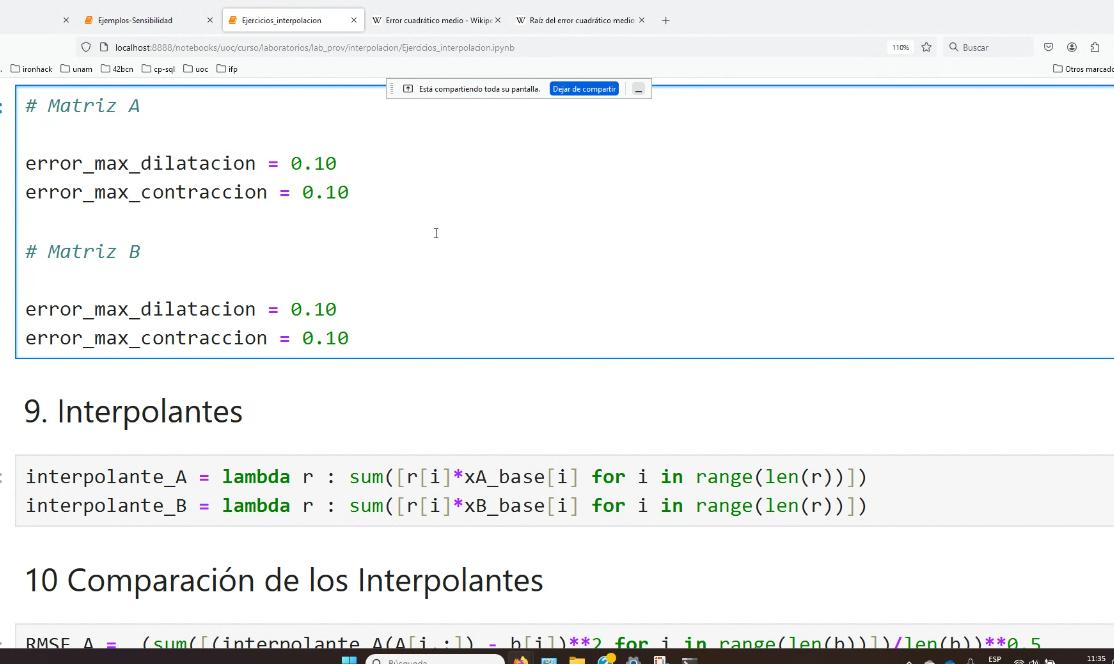

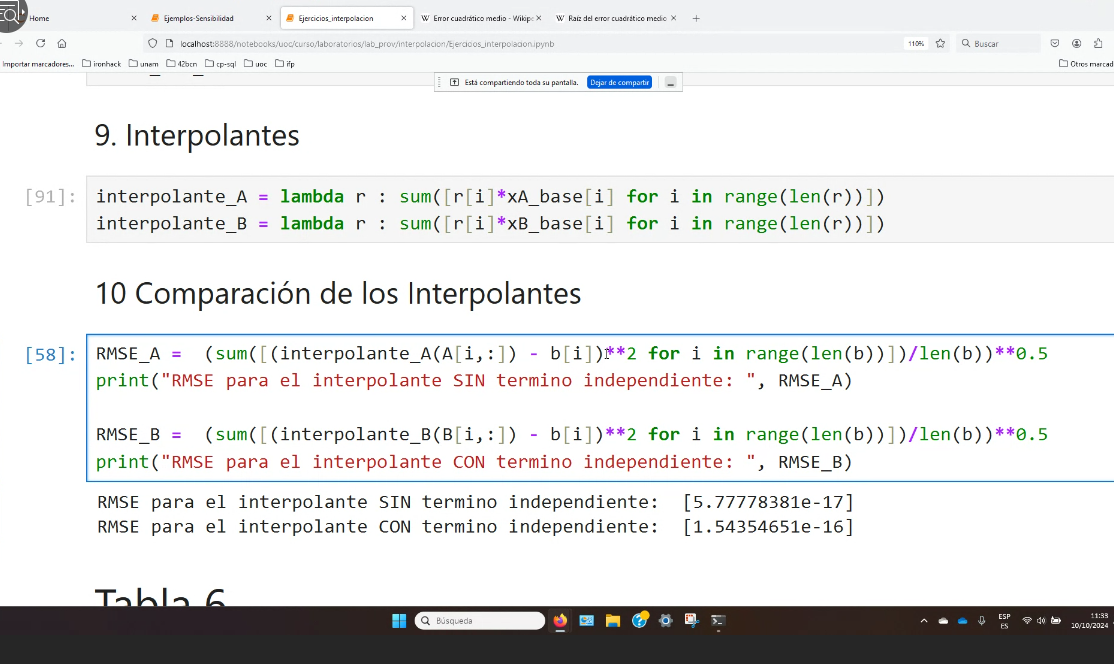

In [46]:
class Interpolator:

    dilataciones = [1.005, 1.01, 1.02, 1.05, 1.10]
    contracciones = [0.995, 0.99, 0.98, 0.95, 0.90]
    interpolante = lambda r, X : sum([r[i]*X[i] for i in range(len(r))])
    error_max_dilatacion = 0.10
    error_max_contraccion = 0.10

    def __init__(self, data, labels_index):
        self.data = data
        self.labels_index = labels_index
        self.A = np.delete(data, labels_index, axis=1)
        self.b = data[:, labels_index].reshape(-1, 1)
        self.B = Interpolator.extended_matrix(np.ones((self.A.shape[0], 1)), self.A)
        self.Ab = Interpolator.extended_matrix(self.A, self.b)
        self.Bb = Interpolator.extended_matrix(self.B, self.b)

    @staticmethod
    def min_ignore_none(a, b):
        if a is not None and b is not None:
            return min(a, b)
        elif a is not None and b is None:
            return a
        elif a is None and b is not None:
            return b
        else:
            return None
        
    @staticmethod
    def extended_matrix(x, y):
        return np.hstack((x, y))

    @staticmethod
    def det(x):
        try:
            return np.linalg.det(x)
        except np.linalg.LinAlgError as e:
            return None

    @staticmethod
    def rank(x):
        return np.linalg.matrix_rank(x)


    @staticmethod
    def clasifica(X, Xb):
        # Segun documentacion de pag 9 de Interpolacion-Extrapolacion.pdf
        rX = Interpolator.rank(X)
        rXb = Interpolator.rank(Xb)
        nX = X.shape[1]

        if rX == rXb :
            if rX == nX:
                return "Sistema Compatible Determinado (SCD)", rX, rXb, nX
            elif rX < nX:
                return "Sistema Compatible Indeterminado (SCI)", rX, rXb, nX
        else:
            return "Sistema Incompatible (SIC)", rX, rXb, nX

    @staticmethod
    def np_inv(x):
        try:
            return np.linalg.inv(x)
        except np.linalg.LinAlgError as e:
            return None

    @staticmethod
    def np_pinv(x):
        try:
            return np.linalg.pinv(x)
        except np.linalg.LinAlgError as e:
            return None

    @staticmethod
    def np_dot(x, y):
        try:
            return np.dot(x, y)
        except np.linalg.LinAlgError as e:
            return None
        except TypeError as e:
            return None

    @staticmethod
    def solve_system(X, b, clase):
        x_inv = None
        if clase == "Sistema Compatible Determinado (SCD)":
            x_inv = np_inv(X)
        elif clase == "Sistema Compatible Indeterminado (SCI)":
            x_inv = np_pinv(X)
        else:
            return None, None

        x_base = np_dot(x_inv, b)
        bX_base = np_dot(X, x_base)
        return x_base, bX_base

    @staticmethod
    def analize_error(xX_base, bX_base, X):
        x_perturbadas = lambda x, lista: [x * i for i in lista]
        b_perturbadas = lambda M, lista : [M.dot(i) for i in lista]
        error_relativo_dil_x = {'label': '', 'errores': [], 'factores': []}
        error_relativo_dil_b = {'label': '', 'errores': [], 'factores': []}
        error_relativo_cont_x = {'label': '', 'errores': [], 'factores': []}
        error_relativo_cont_b = {'label': '', 'errores': [], 'factores': []}

        if (xX_base is not None):
            xX_dil = x_perturbadas(xX_base, Interpolator.dilataciones)
            xX_cont = x_perturbadas(xX_base, Interpolator.contracciones)
            bX_dil = b_perturbadas(X, xX_dil)
            bX_cont = b_perturbadas(X, xX_cont)

            error_relativo_dil_x['label'] = 'Error de x_base con dilatación {0}% : {1}%'
            error_relativo_dil_b['label'] = 'Error de b_base con dilatación {0}% : {1}%'
            error_relativo_cont_x['label'] = 'Error de x_base con contraccion {0}% : {1}%'
            error_relativo_cont_b['label'] = 'Error de b_base con contraccion {0}% : {1}%'
            error_relativo_dil_x['factores'] = Interpolator.dilataciones
            error_relativo_dil_b['factores'] = Interpolator.dilataciones
            error_relativo_cont_x['factores'] = Interpolator.contracciones
            error_relativo_cont_b['factores'] = Interpolator.contracciones
            for i in range(len(Interpolator.dilataciones)):
                error_relativo = np.linalg.norm(xX_base - xX_dil[i]) / np.linalg.norm(xX_base)
                error_porcentual = error_relativo * 100
                error_relativo_dil_x['errores'].append(error_relativo)
                
            for i in range(len(Interpolator.dilataciones)):
                error_relativo = np.linalg.norm(bX_base - bX_dil[i]) / np.linalg.norm(bX_base)
                error_porcentual = error_relativo * 100
                error_relativo_dil_b['errores'].append(error_relativo)
            for i in range(len(Interpolator.contracciones)):
                error_relativo = np.linalg.norm(xX_base - xX_cont[i]) / np.linalg.norm(xX_base)
                error_porcentual = error_relativo * 100
                error_relativo_cont_x['errores'].append(error_relativo)
            for i in range(len(Interpolator.contracciones)):
                error_relativo = np.linalg.norm(bX_base - bX_cont[i]) / np.linalg.norm(bX_base)
                error_porcentual = error_relativo * 100
                error_relativo_cont_b['errores'].append(error_relativo)

        return [error_relativo_dil_x, error_relativo_dil_b, error_relativo_cont_x, error_relativo_cont_b]

    @staticmethod
    def solve_single( X, b, Xb):

        cl, rX, rXb, nX = Interpolator.clasifica(X, Xb)
        xX_base = bX_base = RMSE_X = None
        errores = []
        if cl == "Sistema Incompatible (SIC)" : return cl, rX, rXb, nX, xX_base, bX_base, RMSE_X, errores

        xX_base, bX_base = Interpolator.solve_system(X, b, cl)
        errores = Interpolator.analize_error(xX_base, bX_base, X)

        RMSE_X = Interpolator.interpolar(xX_base, b)

        return cl, rX, rXb, nX, xX_base, bX_base, RMSE_X, errores

    @staticmethod
    def find_best(tabla):
        best_col = None
        best_result = float('inf')
        for i in range(len(tabla[0])):
            # print("Columna de termino dependiente:", i)
            des = Interpolator(tabla, i).solve_all().get_min_error_mean()
            best_result = Interpolator.min_ignore_none(best_result, des)
            if best_result == des:
                best_col = i

        print(f'La solucion más estable es con la columna {best_col}, con una desviación de {best_result}')
        return best_col

    @staticmethod
    def interpolar(X, b):
        return (sum([(Interpolator.interpolante(X[i,:], X) - b[i])**2 for i in range(len(b))])/len(b))**0.5

    def solve_all(self):

        self.cA, self.rA, self.rAb, self.nA, self.xA_base, self.bA_base, self.RMSE_A, self.erroresA = Interpolator.solve_single(self.A, self.b, self.Ab)
        self.cB, self.rB, self.rBb, self.nB, self.xB_base, self.bB_base, self.RMSE_B, self.erroresB = Interpolator.solve_single(self.B, self.b, self.Bb)
        return self

    def print_error_detail(self):
        print("Matriz A:", self.cA)
        for e in range(len(self.erroresA)):
            for i in range(len(self.erroresA[e]['factores'])):
                print(self.erroresA[e]['label'].format(round((self.erroresA[e]['factores'][i]-1)*100,4), round(self.erroresA[e]['errores'][i] * 100,4)))
        
        print("RMSE para el interpolante CON termino independiente: ", self.RMSE_A)
        
        print("Matriz B:", self.cB)
        for e in range(len(self.erroresB)):
            print('')
            for i in range(len(self.erroresB[e]['factores'])):
                print(self.erroresB[e]['label'].format(round((self.erroresB[e]['factores'][i]-1)*100,4), round(self.erroresB[e]['errores'][i] * 100,4)))

        print("RMSE para el interpolante CON termino independiente: ", self.RMSE_B)

        return self

    def get_min_error_mean(self):

        errA = [np.subtract(err['factores'],err['errores']) for err in self.erroresA]
        des_media_A = round(np.mean(errA)-1, 4) if len(errA) > 0 else None
        # print("Matriz A:", self.cA, ", Media de deviación con pertubaciones:", des_media_A)
        errB = [np.subtract(err['factores'],err['errores']) for err in self.erroresB]
        des_media_B = round(np.mean(errB)-1, 4) if len(errB) > 0 else None
        # print("Matriz B:", self.cB, ", Media de deviación con pertubaciones:", des_media_B)
        
        return Interpolator.min_ignore_none(des_media_A , des_media_B )


In [47]:

for tabla in tablas:
    Interpolator(tabla['datos'],5).solve_all().print_error_detail()


Matriz A: Sistema Incompatible (SIC)
RMSE para el interpolante CON termino independiente:  None
Matriz B: Sistema Compatible Determinado (SCD)

Error de x_base con dilatación 0.5% : 0.5%
Error de x_base con dilatación 1.0% : 1.0%
Error de x_base con dilatación 2.0% : 2.0%
Error de x_base con dilatación 5.0% : 5.0%
Error de x_base con dilatación 10.0% : 10.0%

Error de b_base con dilatación 0.5% : 0.5%
Error de b_base con dilatación 1.0% : 1.0%
Error de b_base con dilatación 2.0% : 2.0%
Error de b_base con dilatación 5.0% : 5.0%
Error de b_base con dilatación 10.0% : 10.0%

Error de x_base con contraccion -0.5% : 0.5%
Error de x_base con contraccion -1.0% : 1.0%
Error de x_base con contraccion -2.0% : 2.0%
Error de x_base con contraccion -5.0% : 5.0%
Error de x_base con contraccion -10.0% : 10.0%

Error de b_base con contraccion -0.5% : 0.5%
Error de b_base con contraccion -1.0% : 1.0%
Error de b_base con contraccion -2.0% : 2.0%
Error de b_base con contraccion -5.0% : 5.0%
Error de b_b